In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc

In [3]:
column_names = [
    'ID',
    'Diagnosis',
    'mean radius', 'mean texture', 'mean perimeter', 'mean area',
    'mean smoothness', 'mean compactness', 'mean concavity',
    'mean concave points', 'mean symmetry', 'mean fractal dimension',
    'radius se', 'texture se', 'perimeter se', 'area se',
    'smoothness se', 'compactness se', 'concavity se',
    'concave points se', 'symmetry se', 'fractal dimension se',
    'worst radius', 'worst texture', 'worst perimeter', 'worst area',
    'worst smoothness', 'worst compactness', 'worst concavity',
    'worst concave points', 'worst symmetry', 'worst fractal dimension'
]

df = pd.read_csv("/content/wdbc.data", names=column_names)

# Drop the ID column as it's not needed for analysis
df = df.drop(columns=['ID'])

# Map 'M' to 1 (malignant) and 'B' to 0 (benign) for the 'Diagnosis' column
df['Diagnosis'] = df['Diagnosis'].map({'M': 1, 'B': 0})

# Display first 5 rows
print("--- First 5 rows of the dataset ---")
display(df.head())

# Compute summary statistics (mean, median, standard deviation, etc.)
print("\n--- Summary Statistics ---")
display(df.describe())

--- First 5 rows of the dataset ---


,Diagnosis,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



--- Summary Statistics ---


,Diagnosis,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [4]:
# 3. Check for missing values and duplicates
print("Missing values in each column:\n", df.isnull().sum().sum())
print("Number of duplicate rows:", df.duplicated().sum())

# Drop duplicates if any
df = df.drop_duplicates()

# Handling Outliers using IQR (Interquartile Range) method for a smooth Logistic Regression
def cap_outliers(dataframe):
    df_capped = dataframe.copy()
    for col in df_capped.columns[:-1]: # Skip the target column 'Outcome'
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Capping the outliers to upper and lower bounds
        df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound,
                                  np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col]))
    return df_capped

df_clean = cap_outliers(df)
print("\nOutliers have been capped using the IQR method.")

Missing values in each column:
 0
Number of duplicate rows: 0

Outliers have been capped using the IQR method.


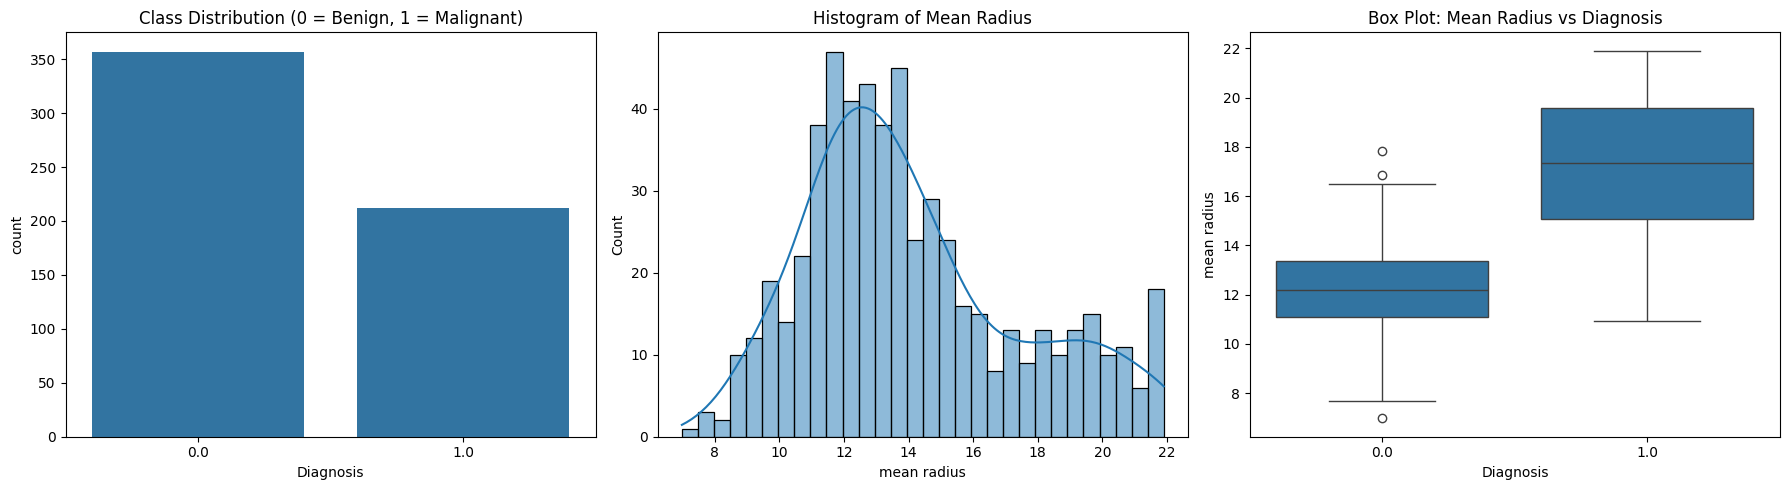

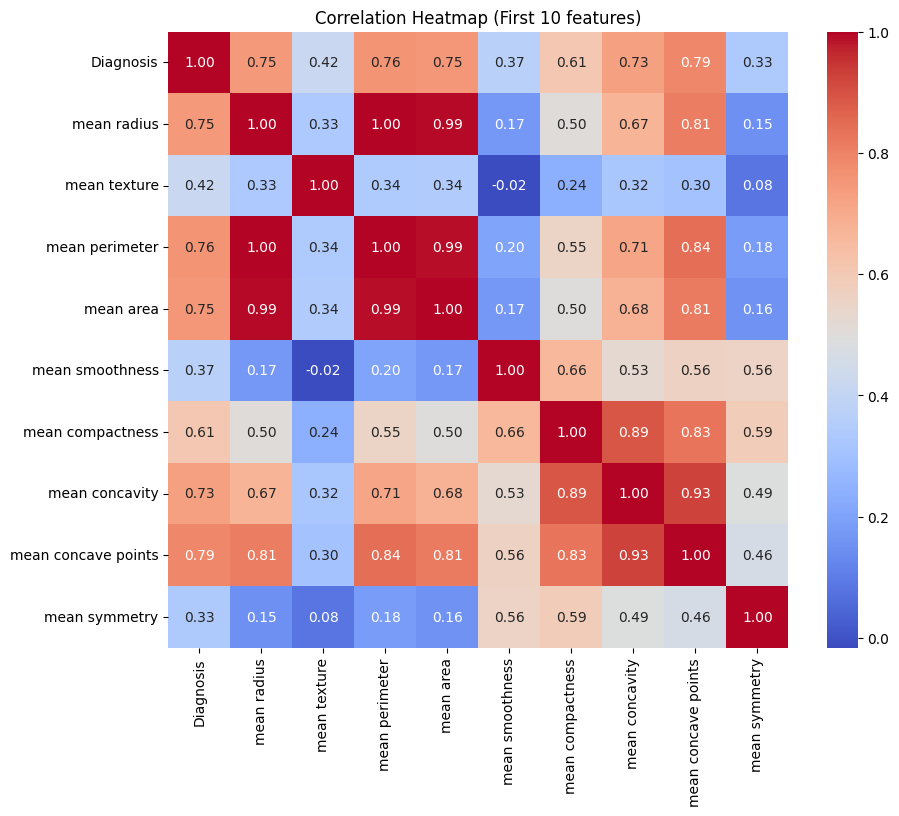


Class Distribution Counts:
 Diagnosis
0.0    357
1.0    212
Name: count, dtype: int64


In [5]:
# 4. Visualize the data
plt.figure(figsize=(18, 5))

# Class Distribution
plt.subplot(1, 3, 1)
sns.countplot(x='Diagnosis', data=df_clean)
plt.title("Class Distribution (0 = Benign, 1 = Malignant)")

# Histogram for a key feature
plt.subplot(1, 3, 2)
sns.histplot(df_clean['mean radius'], kde=True, bins=30)
plt.title("Histogram of Mean Radius")

# Box plot for a key feature
plt.subplot(1, 3, 3)
sns.boxplot(x='Diagnosis', y='mean radius', data=df_clean)
plt.title("Box Plot: Mean Radius vs Diagnosis")
plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
# Taking a subset of features for better visibility in heatmap
subset_cols = df_clean.columns[:10]
sns.heatmap(df_clean[subset_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (First 10 features)")
plt.show()

# 5. Class Imbalance Check
print("\nClass Distribution Counts:\n", df_clean['Diagnosis'].value_counts())

In [7]:
# 1. Encode the target variable (Already binary in this dataset: 0 and 1)
X = df_clean.drop('Diagnosis', axis=1)
y = df_clean['Diagnosis']

# 2. Split the data (80/20 split) using stratified sampling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# 3. Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (455, 30)
Testing data shape: (114, 30)


In [8]:
# Train a logistic regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression Model trained successfully!")

Logistic Regression Model trained successfully!


--- Model Evaluation Metrics ---
Accuracy: 0.9649122807017544

Classification Report (Precision, Recall, F1-score):

              precision    recall  f1-score   support

         0.0       0.96      0.99      0.97        72
         1.0       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



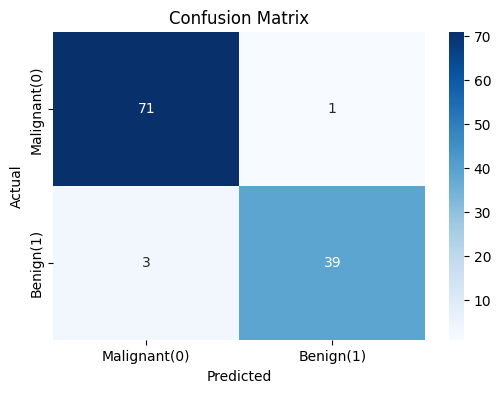

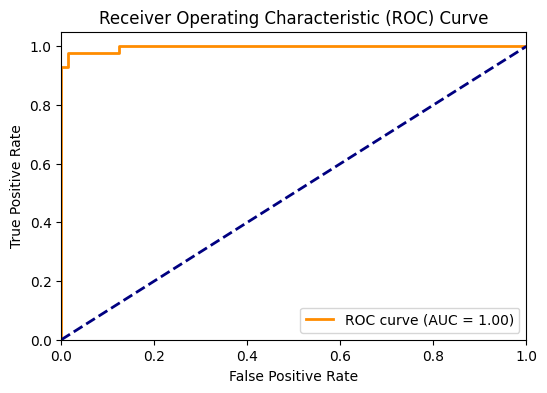

In [9]:
# Make predictions
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# 1. Evaluate Metrics
print("--- Model Evaluation Metrics ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report (Precision, Recall, F1-score):\n")
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix Visualization
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Malignant(0)', 'Benign(1)'], yticklabels=['Malignant(0)', 'Benign(1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# 3. ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()